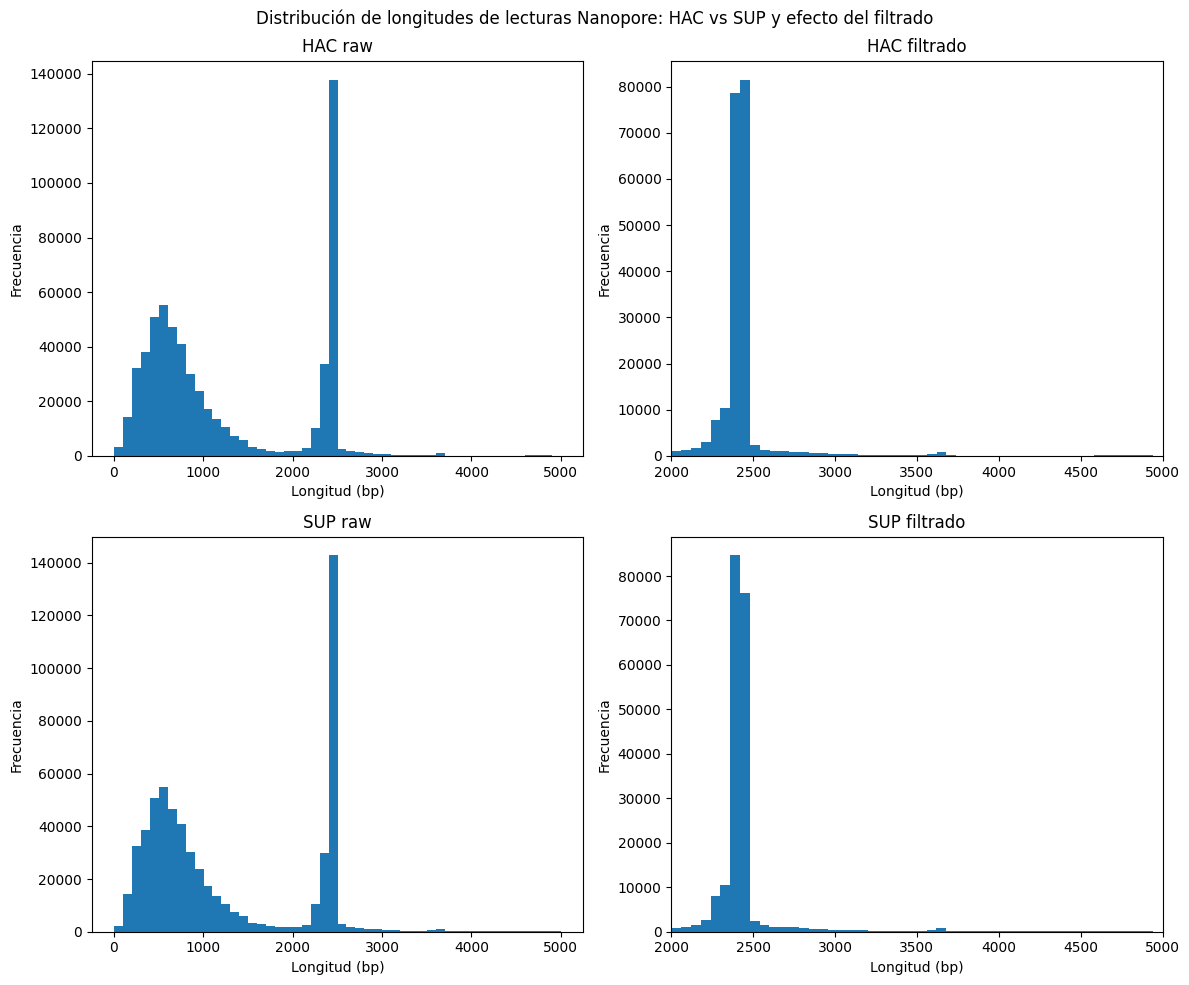

In [19]:
import matplotlib.pyplot as plt
from Bio import SeqIO

# Archivos
hac_raw = "hac.fastq"
hac_filtered = "hac_filtered.fastq"
sup_raw = "sup.fastq"
sup_filtered = "sup_filtered.fastq"

def get_lengths(file):
    return [len(record.seq) for record in SeqIO.parse(file, "fastq")]

# Cargar datos
hac_raw_len = get_lengths(hac_raw)
hac_filt_len = get_lengths(hac_filtered)
sup_raw_len = get_lengths(sup_raw)
sup_filt_len = get_lengths(sup_filtered)

# -------------------------
# Figura 2x2
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# HAC raw
hac_raw_vis = [x for x in hac_raw_len if x < 5000]
axes[0,0].hist(hac_raw_vis, bins=50)
axes[0,0].set_title("HAC raw")

# HAC filtrado
axes[0,1].hist(hac_filt_len, bins=50)
axes[0,1].set_title("HAC filtrado")
axes[0,1].set_xlim(2000, 5000)

# SUP raw
sup_raw_vis = [x for x in sup_raw_len if x < 5000]
axes[1,0].hist(sup_raw_vis, bins=50)
axes[1,0].set_title("SUP raw")

# SUP filtrado
axes[1,1].hist(sup_filt_len, bins=50)
axes[1,1].set_title("SUP filtrado")
axes[1,1].set_xlim(2000, 5000)

# Etiquetas comunes
for ax in axes.flat:
    ax.set_xlabel("Longitud (bp)")
    ax.set_ylabel("Frecuencia")

plt.suptitle("Distribución de longitudes de lecturas Nanopore: HAC vs SUP y efecto del filtrado")

plt.tight_layout()
plt.savefig("length_distribution_4panel.png", dpi=300)
plt.show()

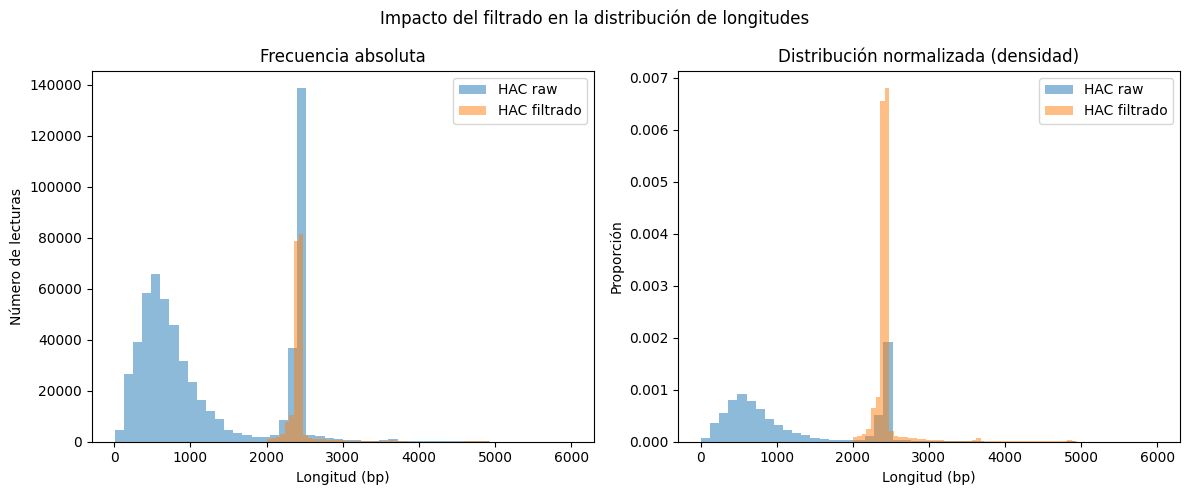

In [17]:
import matplotlib.pyplot as plt

# -------------------------
# Figura 2 paneles
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -------- PANEL A: FRECUENCIA (lo que ya viste)
axes[0].hist(hac_raw_vis, bins=50, alpha=0.5, label="HAC raw")
axes[0].hist(hac_filt_len, bins=50, alpha=0.5, label="HAC filtrado")

axes[0].set_title("Frecuencia absoluta")
axes[0].set_xlabel("Longitud (bp)")
axes[0].set_ylabel("Número de lecturas")
axes[0].legend()

# -------- PANEL B: DENSIDAD (esto es lo importante)
axes[1].hist(hac_raw_vis, bins=50, density=True, alpha=0.5, label="HAC raw")
axes[1].hist(hac_filt_len, bins=50, density=True, alpha=0.5, label="HAC filtrado")

axes[1].set_title("Distribución normalizada (densidad)")
axes[1].set_xlabel("Longitud (bp)")
axes[1].set_ylabel("Proporción")
axes[1].legend()

plt.suptitle("Impacto del filtrado en la distribución de longitudes")

plt.tight_layout()
plt.savefig("length_distribution_normalized.png", dpi=300)
plt.show()

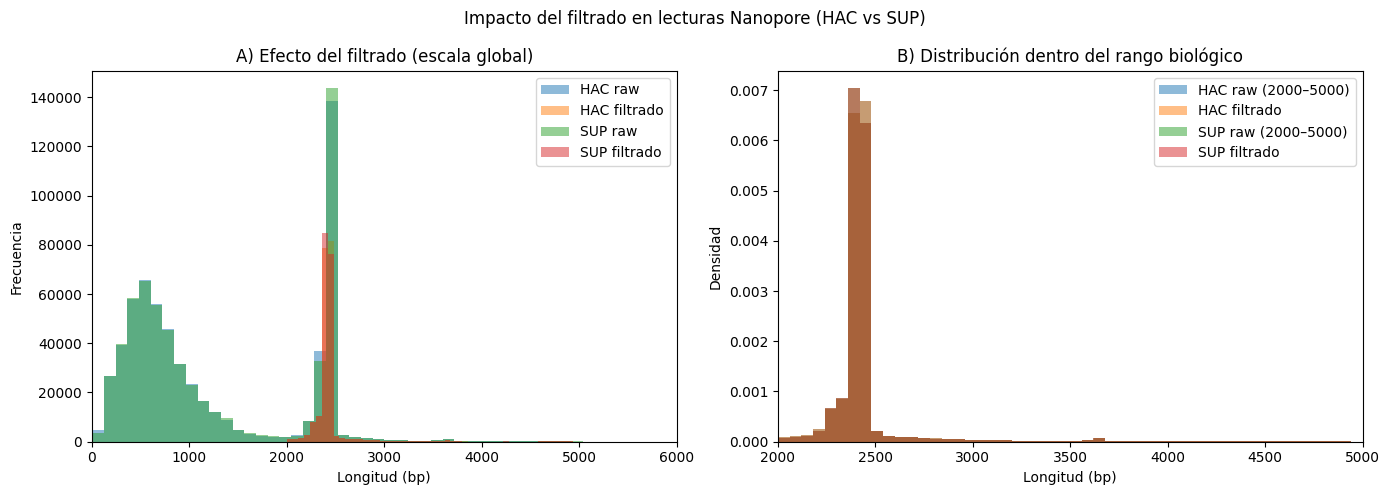

In [18]:
import matplotlib.pyplot as plt
from Bio import SeqIO

# -------------------------
# Archivos
# -------------------------
hac_raw = "hac.fastq"
hac_filtered = "hac_filtered.fastq"
sup_raw = "sup.fastq"
sup_filtered = "sup_filtered.fastq"

# -------------------------
# Función
# -------------------------
def get_lengths(file):
    return [len(record.seq) for record in SeqIO.parse(file, "fastq")]

# -------------------------
# Cargar datos
# -------------------------
hac_raw_len = get_lengths(hac_raw)
hac_filt_len = get_lengths(hac_filtered)
sup_raw_len = get_lengths(sup_raw)
sup_filt_len = get_lengths(sup_filtered)

# -------------------------
# Filtrado SOLO para visualización
# -------------------------
# eliminar outliers extremos
hac_raw_vis = [x for x in hac_raw_len if x < 6000]
sup_raw_vis = [x for x in sup_raw_len if x < 6000]

# restringir al rango biológico
hac_raw_2000_5000 = [x for x in hac_raw_len if 2000 <= x <= 5000]
sup_raw_2000_5000 = [x for x in sup_raw_len if 2000 <= x <= 5000]

# -------------------------
# FIGURA FINAL (2 paneles)
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# -------------------------
# PANEL A — efecto global
# -------------------------
axes[0].hist(hac_raw_vis, bins=50, alpha=0.5, label="HAC raw")
axes[0].hist(hac_filt_len, bins=50, alpha=0.5, label="HAC filtrado")

axes[0].hist(sup_raw_vis, bins=50, alpha=0.5, label="SUP raw")
axes[0].hist(sup_filt_len, bins=50, alpha=0.5, label="SUP filtrado")

axes[0].set_title("A) Efecto del filtrado (escala global)")
axes[0].set_xlabel("Longitud (bp)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, 6000)
axes[0].legend()

# -------------------------
# PANEL B — comparación correcta
# -------------------------
axes[1].hist(hac_raw_2000_5000, bins=50, density=True, alpha=0.5, label="HAC raw (2000–5000)")
axes[1].hist(hac_filt_len, bins=50, density=True, alpha=0.5, label="HAC filtrado")

axes[1].hist(sup_raw_2000_5000, bins=50, density=True, alpha=0.5, label="SUP raw (2000–5000)")
axes[1].hist(sup_filt_len, bins=50, density=True, alpha=0.5, label="SUP filtrado")

axes[1].set_title("B) Distribución dentro del rango biológico")
axes[1].set_xlabel("Longitud (bp)")
axes[1].set_ylabel("Densidad")
axes[1].set_xlim(2000, 5000)
axes[1].legend()

# -------------------------
# FINAL
# -------------------------
plt.suptitle("Impacto del filtrado en lecturas Nanopore (HAC vs SUP)")

plt.tight_layout()
plt.savefig("length_distribution_final.png", dpi=300)
plt.show()